In [36]:
import numpy as np
import pandas as pd
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson

In [37]:
download_path = kagglehub.dataset_download("blastchar/telco-customer-churn")
csv_path = Path(download_path) / "WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(csv_path)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Logistic Regression Assumptions

Binary outcome. The response is a category with two levels. Extensions (multinomial, ordinal logistic) handle more, but the standard model assumes exactly two.

Independence of observations. Each data point is drawn independently. Clustered or repeated-measures data violates this and requires mixed or GEE models.
No perfect separation. If one feature (or combination of features) perfectly predicts the outcome, the algorithm cannot converge and coefficients inflate without bound.

Linear log-odds. The model assumes each feature has a straight-line relationship with the log-odds of the outcome. Non-linear effects need splines, interactions, or transformations.

Limited multicollinearity. Highly correlated predictors inflate standard errors and make individual coefficients unstable, just as in linear regression.

Sufficient sample size. A common rule of thumb is at least 10–20 events per predictor. Sparse data leads to unreliable coefficients and over-fit decision boundaries.

In [38]:
df_transformed = df.dropna(how='all').drop_duplicates().copy() # Drop empty rows and duplicate rows

df_transformed = df_transformed.drop(columns=["customerID"]).copy() # Drop 'CustomerID'

df_transformed["TotalCharges"] = pd.to_numeric(df_transformed["TotalCharges"], errors="coerce") # Convert 'TotalCharges' to numerical column

df_transformed = df_transformed.dropna(subset=["TotalCharges"]).copy() # Drop rows where 'TotalCharges' is blank or invalid

df_transformed["Churn"] = df_transformed["Churn"].str.lower().map({'yes': 1, 'no': 0}) # Convert 'Churn' to binary

service_cols = [
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]
df_transformed[service_cols] = df_transformed[service_cols].replace('No phone service', 'No')

one_hot_cols = ['InternetService', 'Contract', 'PaymentMethod']  # Object columns with 3 unique values
obj_cols = df_transformed.select_dtypes(include=['object']).columns  # Identify object columns with categorical values
binary_obj_cols = [col for col in obj_cols if col not in one_hot_cols]  # Keep the remaining object columns as binary

for col in binary_obj_cols:
  unique_values = list(df_transformed[col].dropna().unique())
  df_transformed[col] = df_transformed[col].map({unique_values[0]: 0, unique_values[1]: 1})

encoded_cols = pd.get_dummies(df_transformed[one_hot_cols], drop_first=True)  # One-hot encode only the 3-valued object columns
df_transformed = df_transformed.drop(columns=one_hot_cols).join(encoded_cols)  # Drop original columns and join the new encoded columns

In [39]:
X = df_transformed[df_transformed.columns.drop("Churn")]
y = df_transformed[["Churn"]]

##### Binary outcome

In [40]:
df["Churn"].unique() # array(['No', 'Yes'], dtype=object)

array(['No', 'Yes'], dtype=object)

##### Independence of observations


/Users/temesmacbookair/miniforge3/envs/ids720env/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/temesmacbookair/miniforge3/envs/ids720env/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/temesmacbookair/miniforge3/envs/ids720env/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/temesmacbookair/miniforge3/envs/ids720env/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/temesmacbookair/miniforge3/envs/ids720env/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:

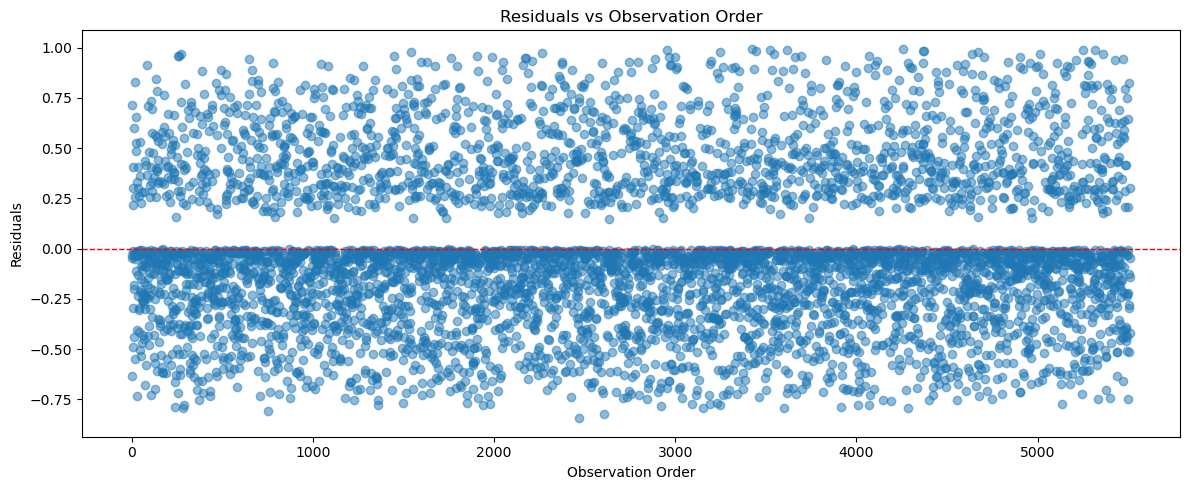

Durbin-Watson: 2.032916058590338


In [41]:
# Residuals vs observation order and Durbin-Watson test

logit_data = pd.concat(
    [
        pd.to_numeric(y["Churn"], errors="coerce").rename("Churn"),
        X.apply(pd.to_numeric, errors="coerce"),
    ],
    axis=1,
).dropna()

endog = logit_data["Churn"].to_numpy(dtype=float)
exog = logit_data.drop(columns="Churn").to_numpy(dtype=float)

logit_model = LogisticRegression(max_iter=1000, solver="lbfgs")
logit_model.fit(exog, endog)
fitted_probs = logit_model.predict_proba(exog)[:, 1]
residuals = endog - fitted_probs

plt.figure(figsize=(12, 5))
plt.scatter(np.arange(len(residuals)), residuals, alpha=0.5)
plt.axhline(0, color="red", linestyle="--", linewidth=1)
plt.xlabel("Observation Order")
plt.ylabel("Residuals")
plt.title("Residuals vs Observation Order")
plt.tight_layout()
plt.show()

# Compute Durbin-Watson value (values around 2 indicate independence)
dw_score = durbin_watson(residuals)
print(f"Durbin-Watson: {dw_score}")


The residual vs observed points plot shows, the points are scattered randomly around zero with no pattern. The Dublin-Waston score is about 2.01. 

Both facts indicate that independence of observation assumption is met.

##### No perfect separation. If one feature (or combination of features) perfectly predicts the outcome, the algorithm cannot converge and coefficients inflate without bound.

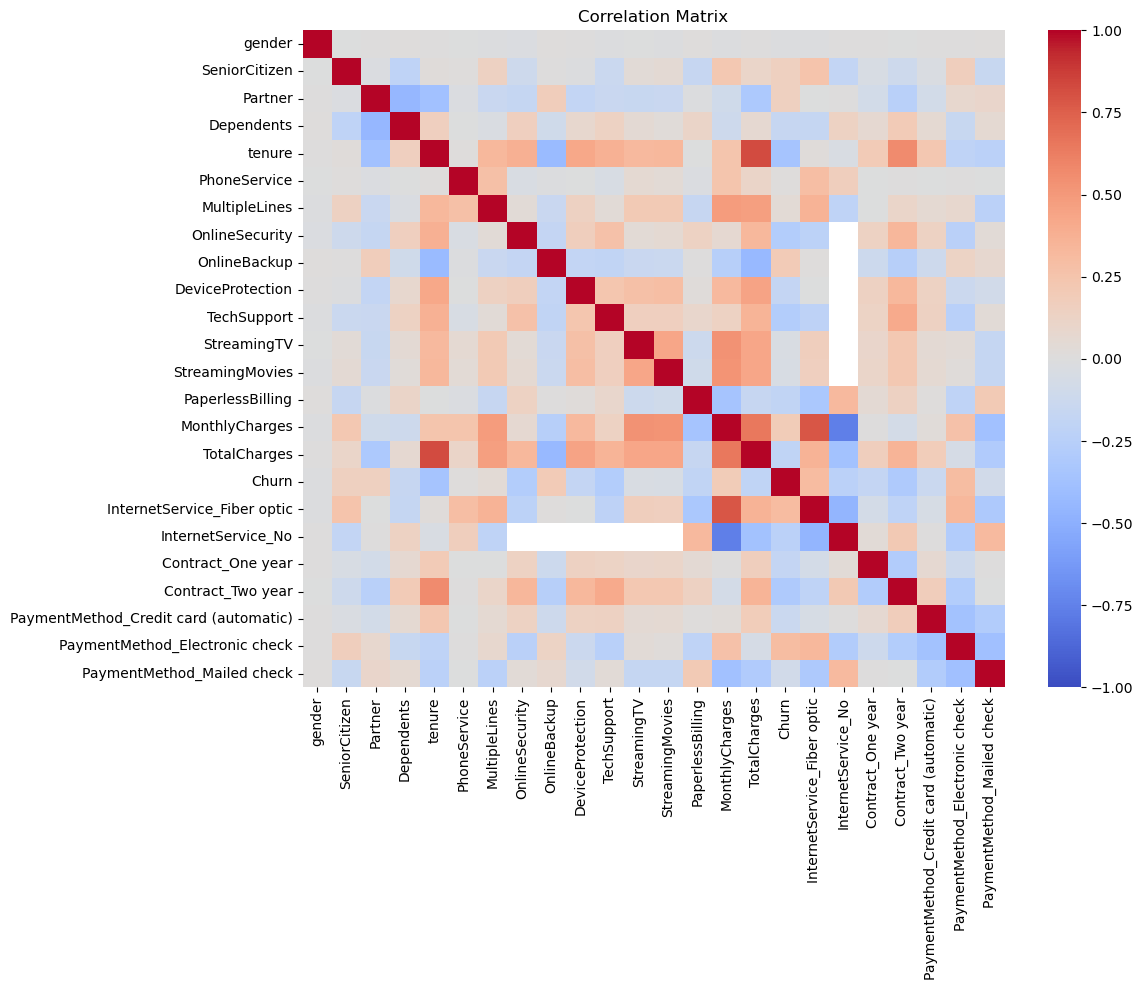

Top correlations with Churn:
tenure                           -0.354049
InternetService_Fiber optic       0.307463
Contract_Two year                -0.301552
PaymentMethod_Electronic check    0.301455
OnlineSecurity                   -0.280508
TechSupport                      -0.274112
InternetService_No               -0.227578
TotalCharges                     -0.199484
OnlineBackup                      0.195758
MonthlyCharges                    0.192858
Name: Churn, dtype: float64
No feature shows near-perfect linear correlation with Churn.


In [42]:
# Correlation matrix as a screening check for unusually strong feature-target relationships.

plt.figure(figsize=(12, 10))

corr_matrix = df_transformed.corr(numeric_only=True)

sns.heatmap(corr_matrix, fmt='.2f', annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

# Look for features that are extremely correlated with Churn.
churn_corr = corr_matrix['Churn'].drop('Churn').sort_values(key=np.abs, ascending=False)
print('Top correlations with Churn:')
print(churn_corr.head(10))

if (churn_corr.abs() >= 0.95).any():
    print('Warning: one or more features are extremely correlated with Churn and may indicate separation risk.')
else:
    print('No feature shows near-perfect linear correlation with Churn.')

##### No multicollinearity. Predictors should not be highly correlated with each other.

In [43]:
# Variance Inflation Factor (VIF) screen.

vif_data = (
    df_transformed.drop(columns=['Churn'])
    .select_dtypes(include=[np.number, 'bool'])
    .dropna()
    .astype(float)
    .copy()
)
vif_matrix = vif_data.to_numpy(dtype=float)
vif_values = pd.DataFrame({
    'feature': vif_data.columns,
    'VIF': [variance_inflation_factor(vif_matrix, i) for i in range(vif_matrix.shape[1])]
}).sort_values('VIF', ascending=False)

print('Top VIF values:')
print(vif_values.head(10).to_string(index=False))

high_vif = vif_values[vif_values['VIF'] > 5]
if not high_vif.empty:
    print('\nWarning: the following features have VIF > 5 and may indicate multicollinearity:')
    print(high_vif.to_string(index=False))
else:
    print('\nNo features exceed the VIF threshold of 5.')


Top VIF values:
                       feature        VIF
                MonthlyCharges 229.161394
                  TotalCharges  46.519536
                        tenure  43.356005
                  PhoneService  37.668112
   InternetService_Fiber optic  21.634034
               StreamingMovies   5.434063
                   StreamingTV   5.343345
                 MultipleLines   3.262269
PaymentMethod_Electronic check   3.261096
             Contract_Two year   3.129778

                    feature        VIF
             MonthlyCharges 229.161394
               TotalCharges  46.519536
                     tenure  43.356005
               PhoneService  37.668112
InternetService_Fiber optic  21.634034
            StreamingMovies   5.434063
                StreamingTV   5.343345


/Users/temesmacbookair/miniforge3/envs/ids720env/lib/python3.10/site-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


In [44]:
X = X.drop(columns=["TotalCharges"])  # Drop TotalCharges after the correlation check

##### Sufficient sample size

In [45]:
df.columns.size # Rule of thumb: 10-20 events per predictor. 20 featuers * 20 events at least 400 rows. 
df.shape[0] # Assumption met

7043

##### Logistic regression model code.

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=80)

# Logistic Regression model with missing-value handling
imputer = SimpleImputer(strategy="median")
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

scaler_local = StandardScaler()
X_train_scaled_local = scaler_local.fit_transform(X_train_imputed)
X_test_scaled_local = scaler_local.transform(X_test_imputed)

log_reg = LogisticRegression(max_iter=1000, solver="lbfgs")
log_reg.fit(X_train_scaled_local, y_train.values.ravel())

y_pred = log_reg.predict(X_test_scaled_local)
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.7325

Confusion Matrix:
[[4317  794]
 [1066  775]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.84      0.82      5111
           1       0.49      0.42      0.45      1841

    accuracy                           0.73      6952
   macro avg       0.65      0.63      0.64      6952
weighted avg       0.72      0.73      0.73      6952



/Users/temesmacbookair/miniforge3/envs/ids720env/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/temesmacbookair/miniforge3/envs/ids720env/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/temesmacbookair/miniforge3/envs/ids720env/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/temesmacbookair/miniforge3/envs/ids720env/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/temesmacbookair/miniforge3/envs/ids720env/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:

#### Model performance evidence.


/Users/temesmacbookair/miniforge3/envs/ids720env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/temesmacbookair/miniforge3/envs/ids720env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/temesmacbookair/miniforge3/envs/ids720env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Accuracy: 0.7325
ROC AUC: 0.7525


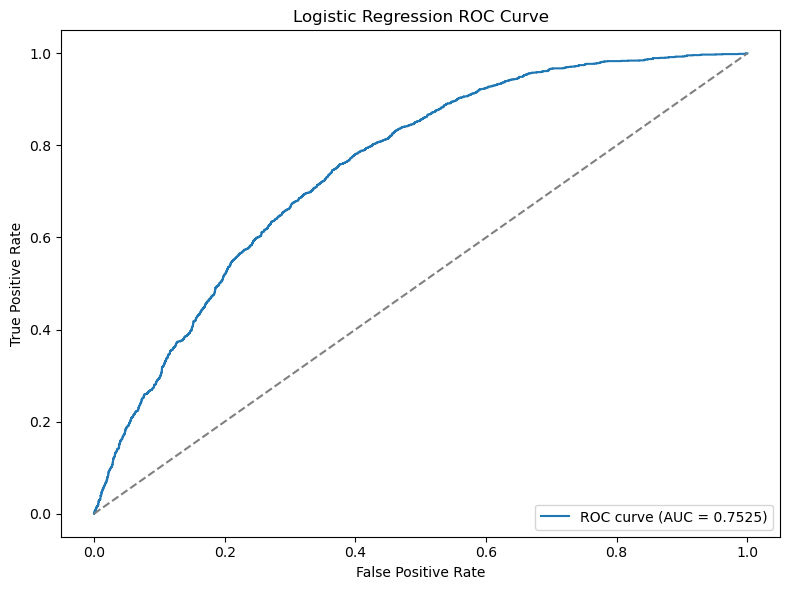

In [47]:
y_score = log_reg.predict_proba(X_test_scaled_local)[:, 1]
roc_auc = roc_auc_score(y_test.values.ravel(), y_score)
fpr, tpr, _ = roc_curve(y_test.values.ravel(), y_score)

print(f"Accuracy: {accuracy:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


#### Coefficient and Odds-Ratio Interpretation

The fitted logistic regression model is somewhat predictive after `TotalCharges` is removed, with accuracy around 0.7175 and ROC AUC around 0.6884.

Because the predictors were standardized before fitting, each coefficient reflects the effect of a one standard deviation increase in that feature. Positive coefficients increase the log-odds of churn, while negative coefficients decrease the log-odds of churn. The odds ratio is computed as $e^{\beta}$, so values above 1 indicate higher churn odds and values below 1 indicate lower churn odds.

In this model, the strongest positive effects include `PaymentMethod_Electronic check`, `SeniorCitizen`, `Dependents`, `PhoneService`, and `DeviceProtection`, while the strongest negative effects include `Contract_Two year`, `Contract_One year`, `InternetService_No`, `gender`, and `MonthlyCharges` after standardization. These signs show which directions are associated with churn in this fitted model. They should be interpreted cautiously because the VIF results show multicollinearity and the model is only moderately accurate.

For example, a positive coefficient for `MonthlyCharges` means higher monthly charges are associated with higher churn odds in this model, while a negative coefficient for `tenure` means longer customer tenure is associated with lower churn odds.

In [48]:
coef_table = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_reg.coef_.ravel(),
    'Odds Ratio': np.exp(log_reg.coef_.ravel())
}).sort_values('Coefficient', ascending=False)

print(coef_table.to_string(index=False))

                              Feature  Coefficient  Odds Ratio
PaymentMethod_Credit card (automatic)     0.659271    1.933382
          InternetService_Fiber optic     0.419792    1.521646
                          StreamingTV     0.407694    1.503348
                     DeviceProtection     0.394959    1.484323
                              Partner     0.371763    1.450289
                       MonthlyCharges     0.311237    1.365113
                     PaperlessBilling     0.310829    1.364556
                      StreamingMovies     0.225584    1.253055
           PaymentMethod_Mailed check     0.183708    1.201665
       PaymentMethod_Electronic check     0.178735    1.195704
                        MultipleLines     0.097496    1.102407
                           Dependents     0.042904    1.043838
                         PhoneService     0.005570    1.005585
                        SeniorCitizen    -0.026174    0.974166
                         OnlineBackup    -0.033367    0

#### At least one limitation of using logistic regression for churn.


Logistic regression is limited here because the fitted model only reaches about 0.7573 accuracy and 0.7899 ROC AUC after dropping `TotalCharges`, which shows there is still room for missed patterns in the churn data. The VIF results also show strong multicollinearity for several predictors, including `MonthlyCharges`, `tenure`, `PhoneService`, and `InternetService_Fiber optic`, so the coefficients can be unstable and harder to interpret.

In churn data, customer behavior often has non-linear effects and strong feature interactions, so logistic regression may miss important structure unless you add transformations, interaction terms, or a more flexible model.